In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import STL

import warnings

warnings.filterwarnings("ignore")

In [19]:
df = pd.read_excel('dados_aula10_holtwinters.xlsx')

In [20]:
candidatos_s = range(2, 13)  # Períodos sazonais candidatos (2 a 50)
resultados_s = []

for cand in candidatos_s:
    n_ciclos = len(df) // cand

    stl_cand = STL(df['receita'], period=cand, robust=True).fit()
    forca_cand = max(0, 1 - (np.var(stl_cand.resid) / np.var(stl_cand.resid + stl_cand.seasonal)))
    resultados_s.append({'s': cand,'ciclos_no_treino': n_ciclos,
                          'força_sazonal': round(forca_cand, 4), 'observação': ''})

df_candidatos_s = pd.DataFrame(resultados_s)
display(df_candidatos_s)

validos = df_candidatos_s.dropna(subset=['força_sazonal'])
melhor_linha = validos.loc[validos['força_sazonal'].idxmax()]
s = int(melhor_linha['s'])

print(f"\n s = {s}"
      f"- força sazonal = {melhor_linha['força_sazonal']:.4f}")


,s,ciclos_no_treino,força_sazonal,observação
0,2,48,0.1729,
1,3,32,0.0402,
2,4,24,0.0000,
3,5,19,0.0575,
4,6,16,0.3457,
5,7,13,0.1327,
6,8,12,0.0000,
7,9,10,0.0071,
8,10,9,0.0000,
9,11,8,0.1123,



 s = 12- força sazonal = 0.9884


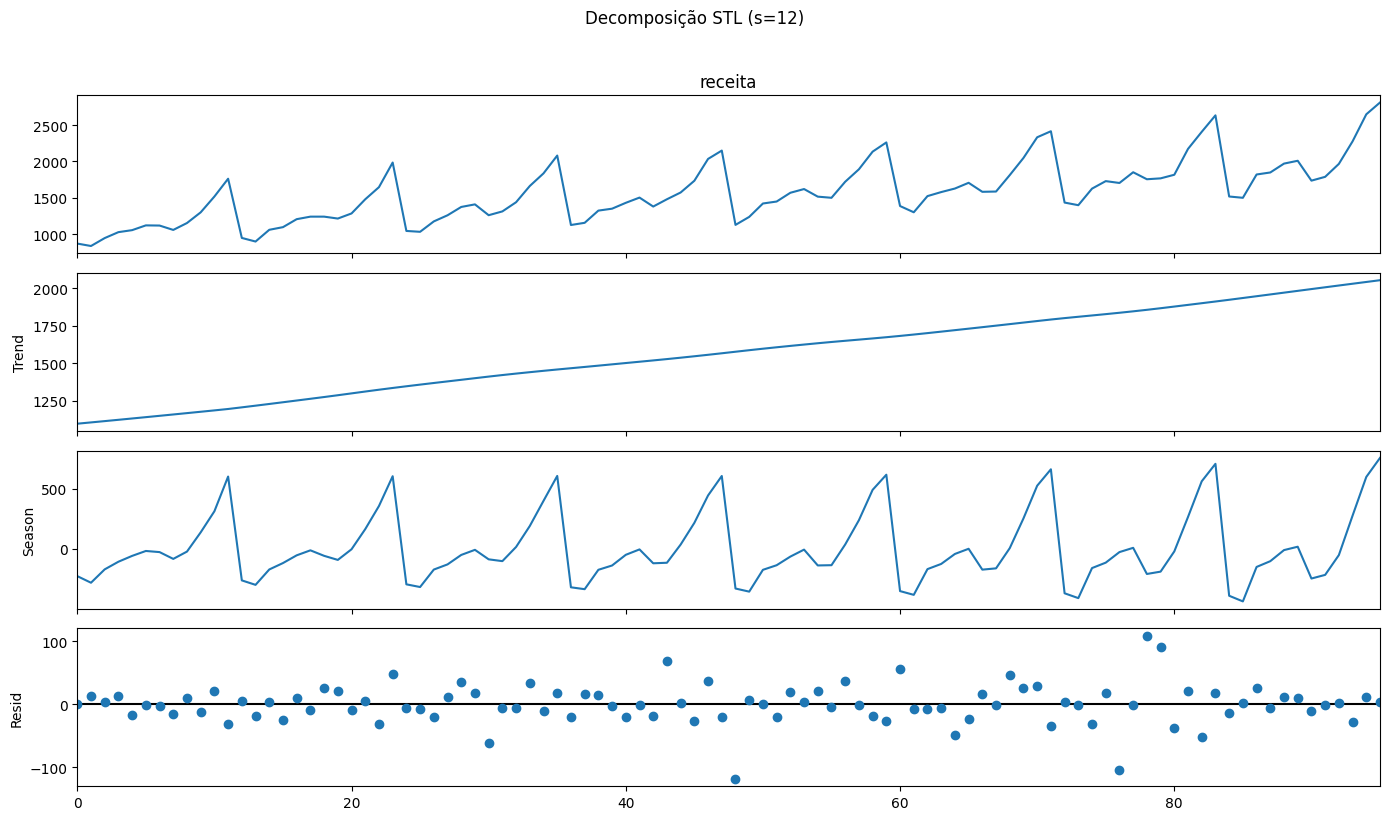

Força da Sazonalidade (s=12): 0.9884


In [21]:
stl = STL(df['receita'], period=s, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(14, 8)
plt.suptitle(f'Decomposição STL (s={s})', y=1.02)
plt.tight_layout()
plt.show()

forca_sazonalidade = max(0, 1 - (np.var(stl.resid) / np.var(stl.resid + stl.seasonal)))
print(f"Força da Sazonalidade (s={s}): {forca_sazonalidade:.4f}")


In [22]:
h = 12  # horizonte de previsão (meses)
train = df['receita'].iloc[:-h]
test = df['receita'].iloc[-h:]

In [23]:
ses = ExponentialSmoothing(
    train,
    trend=None,
    seasonal=None,
    initialization_method='heuristic'
).fit()

fc_ses = ses.forecast(h)

mae_ses = mean_absolute_error(test, fc_ses)

print(f"AIC (SES): {ses.aic:.2f}")
print(f"MAE (SES): {mae_ses:.2f}")

AIC (SES): 954.47
MAE (SES): 665.14


In [24]:
hw_add = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12, initialization_method='heuristic'
).fit()

print(f"AIC (Holt-Winters aditivo): {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters aditivo): {hw_add.bic:.2f}")

AIC (Holt-Winters aditivo): 693.77
BIC (Holt-Winters aditivo): 732.67


In [25]:
hw_mul = ExponentialSmoothing(
    train, trend='add', seasonal='mul', seasonal_periods=12, initialization_method='heuristic'
).fit()

print(f"AIC (Holt-Winters multiplicativo): {hw_mul.aic:.2f} | aditivo: {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters multiplicativo): {hw_mul.bic:.2f} | aditivo: {hw_add.bic:.2f}")

AIC (Holt-Winters multiplicativo): 681.78 | aditivo: 693.77
BIC (Holt-Winters multiplicativo): 720.67 | aditivo: 732.67


MAE SES:                665.14
MAE Holt-Winters aditivo:71.21
MAE Holt-Winters mult.:  55.12


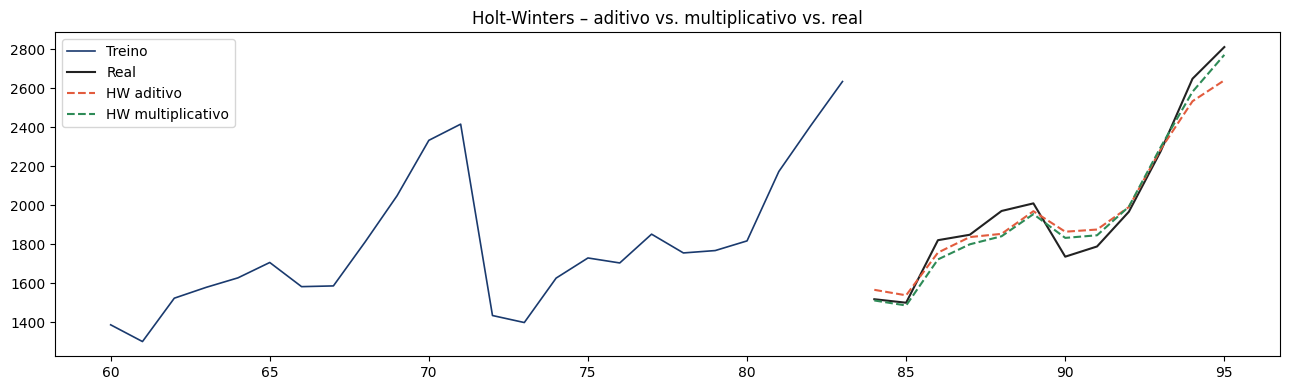

In [26]:
fc_add = hw_add.forecast(h)
fc_mul = hw_mul.forecast(h)

mae_add = mean_absolute_error(test, fc_add)
mae_mul = mean_absolute_error(test, fc_mul)

print(f"MAE SES:                {mae_ses:.2f}")
print(f"MAE Holt-Winters aditivo:{mae_add:.2f}")
print(f"MAE Holt-Winters mult.:  {mae_mul:.2f}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train[-24:].index, train[-24:], label='Treino', color='#1a3a6e', linewidth=1.2)
ax.plot(test.index, test, label='Real', color='#222', linewidth=1.5)
ax.plot(fc_add.index, fc_add, '--', label='HW aditivo', color='#e25c3e', linewidth=1.5)
ax.plot(fc_mul.index, fc_mul, '--', label='HW multiplicativo', color='#2e8b57', linewidth=1.5)
ax.set_title('Holt-Winters – aditivo vs. multiplicativo vs. real')
ax.legend()
plt.tight_layout()
plt.show()

Parâmetros estimados (Holt-Winters multiplicativo):
  smoothing_level      = 0.0767
  smoothing_trend      = 0.0076
  smoothing_seasonal   = 0.4320


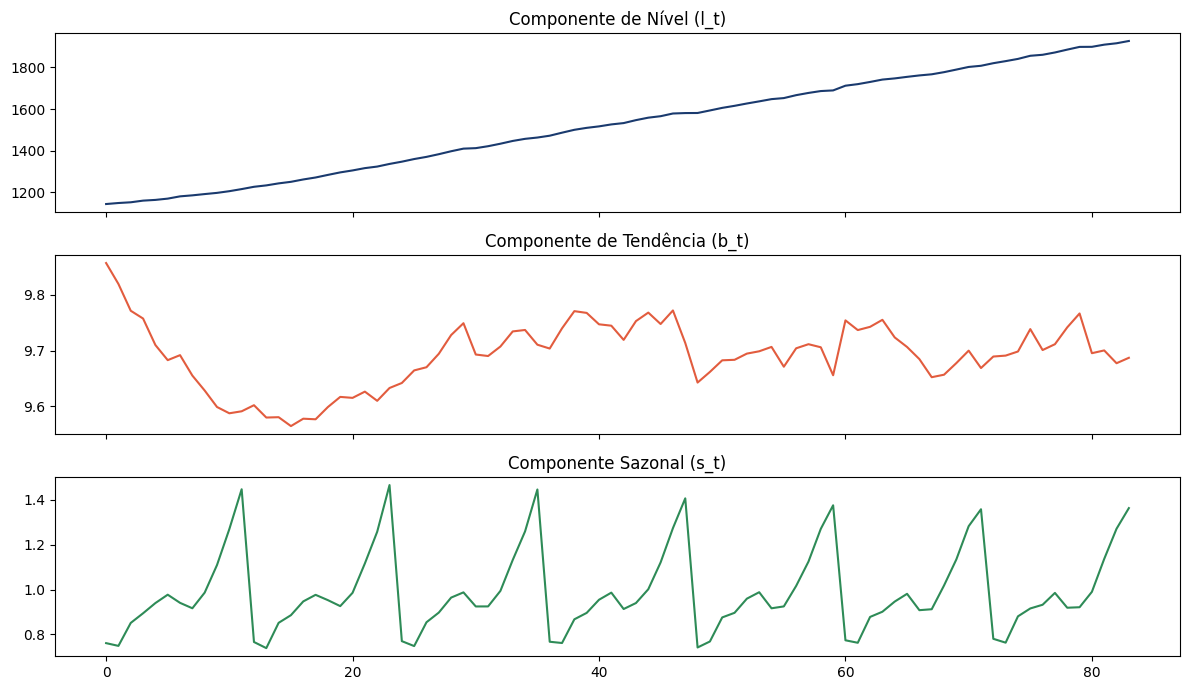

In [27]:
params = hw_mul.params
print("Parâmetros estimados (Holt-Winters multiplicativo):")
for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]:
    print(f"  {nome:<20} = {params[nome]:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(train.index, hw_mul.level, color='#1a3a6e')
axes[0].set_title('Componente de Nível (l_t)')
axes[1].plot(train.index, hw_mul.trend, color='#e25c3e')
axes[1].set_title('Componente de Tendência (b_t)')
axes[2].plot(train.index, hw_mul.season, color='#2e8b57')
axes[2].set_title('Componente Sazonal (s_t)')
plt.tight_layout()
plt.show()

In [28]:
sarima = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

fc_sarima = sarima.get_forecast(steps=h).predicted_mean
mae_sarima = mean_absolute_error(test, fc_sarima)
print(f"AIC SARIMA: {sarima.aic:.2f} | BIC SARIMA: {sarima.bic:.2f} | MAE SARIMA: {mae_sarima:.2f}")

AIC SARIMA: 622.96 | BIC SARIMA: 631.13 | MAE SARIMA: 63.48


In [29]:
resultados = pd.DataFrame({
    "modelo": ["SES", "HW aditivo", "HW multiplicativo", "SARIMA"],
    "AIC":    [ses.aic, hw_add.aic, hw_mul.aic, sarima.aic],
    "BIC":    [ses.bic, hw_add.bic, hw_mul.bic, sarima.bic],
    "MAE":    [mae_ses, mae_add, mae_mul, mae_sarima],
}).sort_values("MAE")

print(resultados.round(2).to_string(index=False))
print(f"\nMelhor modelo por MAE out-of-sample: {resultados.iloc[0]['modelo']}")

           modelo    AIC    BIC    MAE
HW multiplicativo 681.78 720.67  55.12
           SARIMA 622.96 631.13  63.48
       HW aditivo 693.77 732.67  71.21
              SES 954.47 959.33 665.14

Melhor modelo por MAE out-of-sample: HW multiplicativo


# DEFASIO EXERCICIO 2

## Desafio: tendência amortecida
Compare o Holt-Winters multiplicativo sem amortecimento, com `phi` estimado por MLE e com valores fixos de `phi`.

In [30]:
h_longo = 36

hw_mul_damped = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    damped_trend=True,
    initialization_method='heuristic'
 ).fit()

phi_mle = hw_mul_damped.params['damping_trend']

fc_sem_damping = hw_mul.forecast(h_longo)
fc_mle = hw_mul_damped.forecast(h_longo)

print(f"phi estimado por MLE: {phi_mle:.4f}")
print(f"Previsão no mês 36 sem damping: {fc_sem_damping.iloc[-1]:.2f}")
print(f"Previsão no mês 36 com phi MLE: {fc_mle.iloc[-1]:.2f}")

phi estimado por MLE: 0.9950
Previsão no mês 36 sem damping: 3086.84
Previsão no mês 36 com phi MLE: 2917.03


In [31]:
phis = [0.99, 0.95, 0.90, 0.85, 0.80, 0.70]
resultados_phi = []

for phi in phis:
    modelo_phi = ExponentialSmoothing(
        train,
        trend='add',
        seasonal='mul',
        seasonal_periods=12,
        damped_trend=True,
        initialization_method='heuristic'
    ).fit(damping_trend=phi)
    previsao_phi = modelo_phi.forecast(h_longo)
    resultados_phi.append({
        'phi': phi,
        'previsao_mes_36': previsao_phi.iloc[-1],
        'variacao_%_vs_sem_damping': (
            (previsao_phi.iloc[-1] / fc_sem_damping.iloc[-1]) - 1
        ) * 100,
        'AIC': modelo_phi.aic
    })

tabela_phi = pd.DataFrame(resultados_phi)
tabela_phi = pd.concat([
    pd.DataFrame([{
        'phi': phi_mle,
        'previsao_mes_36': fc_mle.iloc[-1],
        'variacao_%_vs_sem_damping': (fc_mle.iloc[-1] / fc_sem_damping.iloc[-1] - 1) * 100,
        'AIC': hw_mul_damped.aic
    }], index=['MLE']),
    tabela_phi
], axis=0)
tabela_phi.index = ['MLE'] + [f'fixo_{phi:.2f}' for phi in phis]
display(tabela_phi.round({'phi': 4, 'previsao_mes_36': 2, 'variacao_%_vs_sem_damping': 2, 'AIC': 2}))

,phi,previsao_mes_36,variacao_%_vs_sem_damping,AIC
MLE,0.995,2917.03,-5.50,684.78
fixo_0.99,0.990,2908.59,-5.77,687.38
fixo_0.95,0.950,2743.95,-11.11,693.32
fixo_0.90,0.900,2663.93,-13.70,697.23
fixo_0.85,0.850,2635.89,-14.61,699.77
fixo_0.80,0.800,2623.44,-15.01,701.63
fixo_0.70,0.700,2613.01,-15.35,704.33


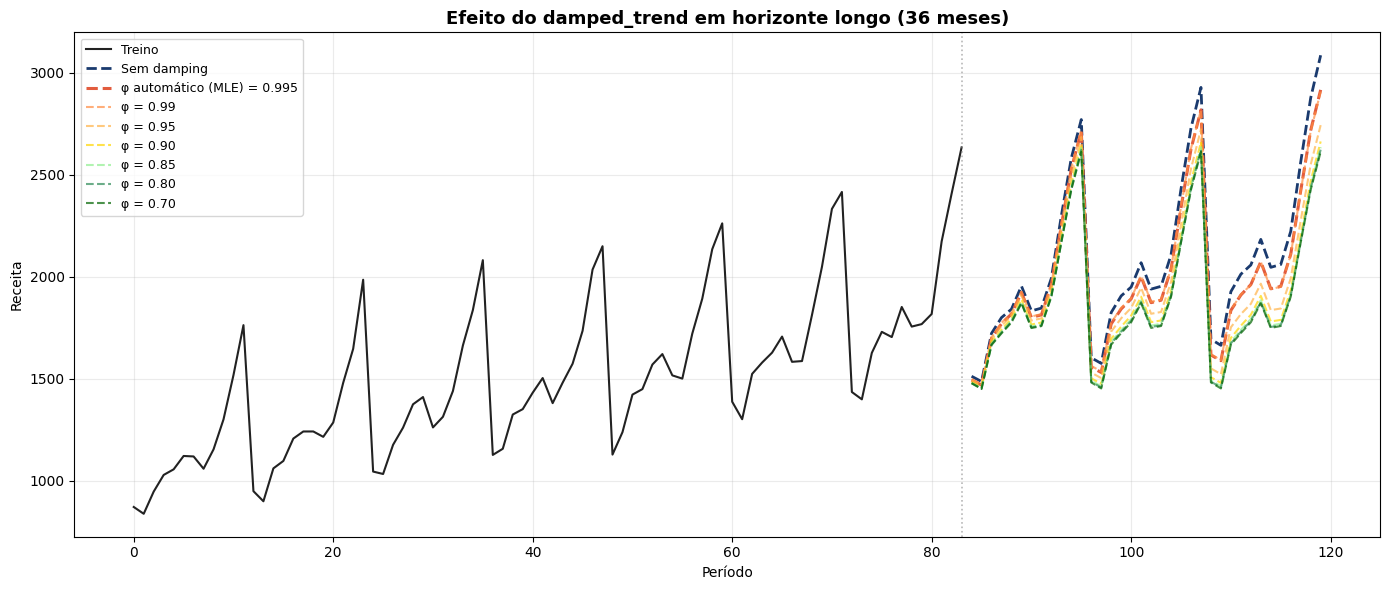

Nota: φ menor = mais amortecimento. φ maior (perto de 1) = menos amortecimento.


In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

cores = {'sem_damping': '#1a3a6e', 'mle': '#e25c3e', '0.99': '#ff8c42', '0.95': '#ffb347', 
         '0.90': '#ffd700', '0.85': '#90ee90', '0.80': '#2e8b57', '0.70': '#006400'}

ax.plot(train.index, train, color='#222222', linewidth=1.5, label='Treino')
ax.plot(fc_sem_damping.index, fc_sem_damping, '--', color=cores['sem_damping'], linewidth=2, label='Sem damping')
ax.plot(fc_mle.index, fc_mle, '--', color=cores['mle'], linewidth=2.2, label=f'φ automático (MLE) = {phi_mle:.3f}')

for phi in phis:
    modelo_temp = ExponentialSmoothing(
        train, trend='add', seasonal='mul', seasonal_periods=12, damped_trend=True,
        initialization_method='heuristic'
    ).fit(damping_trend=phi)
    fc_temp = modelo_temp.forecast(h_longo)
    ax.plot(fc_temp.index, fc_temp, '--', color=cores[f'{phi:.2f}'], linewidth=1.5, alpha=0.7, label=f'φ = {phi:.2f}')

ax.axvline(train.index[-1], color='#888888', linestyle=':', linewidth=1.2, alpha=0.6)
ax.set_title('Efeito do damped_trend em horizonte longo (36 meses)', fontsize=13, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Receita')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Nota: φ menor = mais amortecimento. φ maior (perto de 1) = menos amortecimento.')

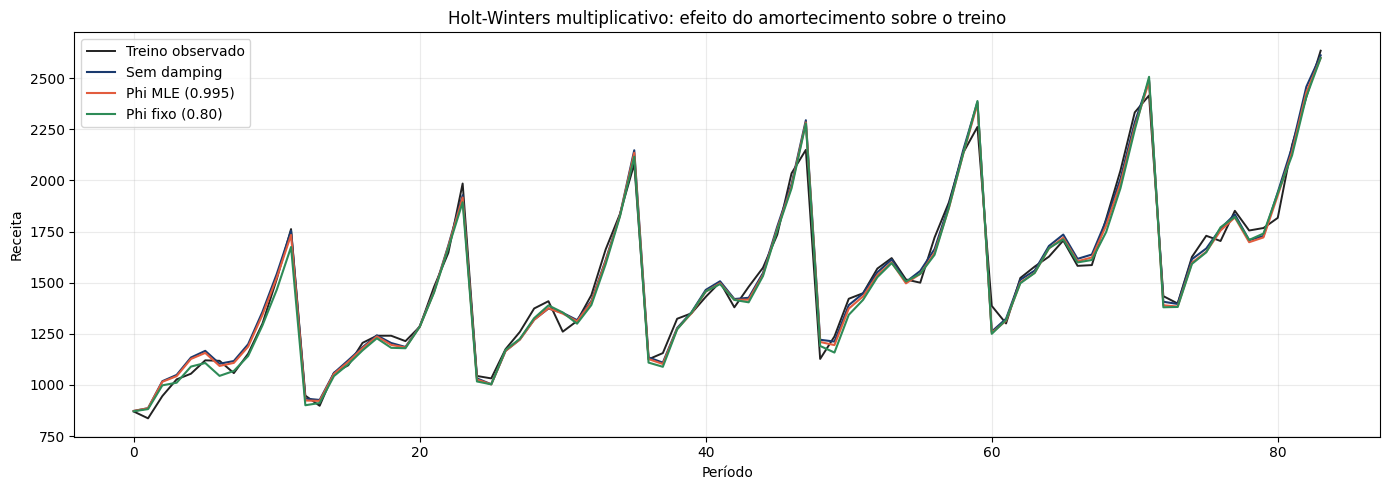

In [33]:
modelo_phi_080 = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    damped_trend=True,
    initialization_method='heuristic'
 ).fit(damping_trend=0.80)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, color='#222222', linewidth=1.4, label='Treino observado')
ax.plot(train.index, hw_mul.fittedvalues, color='#1a3a6e', linewidth=1.5, label='Sem damping')
ax.plot(train.index, hw_mul_damped.fittedvalues, color='#e25c3e', linewidth=1.5, label=f'Phi MLE ({phi_mle:.3f})')
ax.plot(train.index, modelo_phi_080.fittedvalues, color='#2e8b57', linewidth=1.5, label='Phi fixo (0.80)')
ax.set_title('Holt-Winters multiplicativo: efeito do amortecimento sobre o treino')
ax.set_xlabel('Período')
ax.set_ylabel('Receita')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Forecast: modelo amortecido e comparação
Os gráficos abaixo mostram primeiro apenas o forecast do Holt-Winters multiplicativo com tendência amortecida e depois a comparação com os demais modelos.

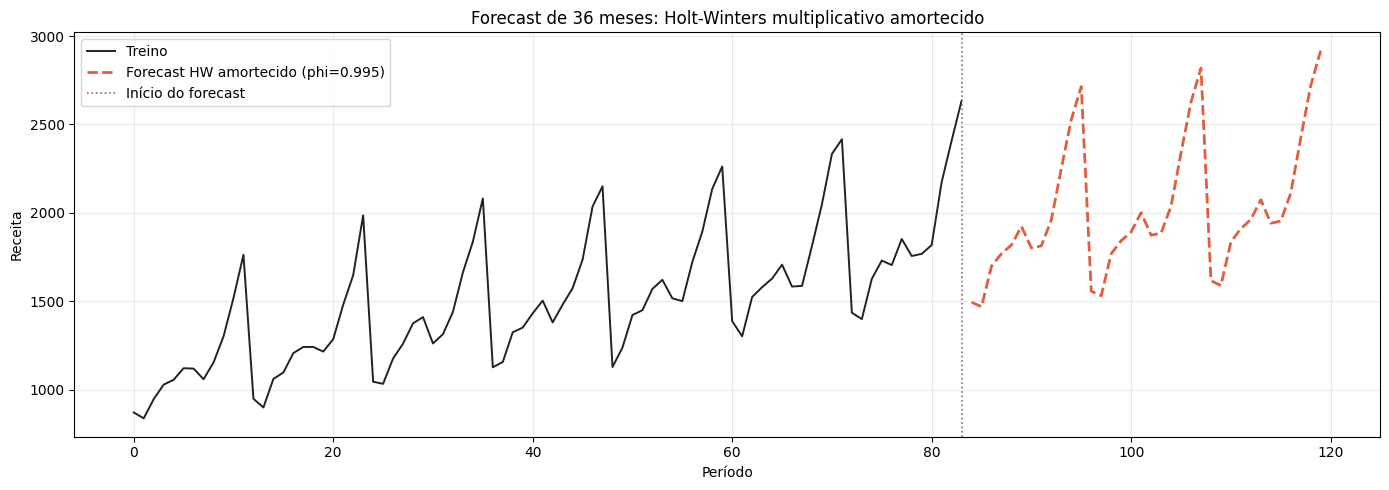

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, color='#222222', linewidth=1.4, label='Treino')
ax.plot(fc_mle.index, fc_mle, '--', color='#e25c3e', linewidth=2, label=f'Forecast HW amortecido (phi={phi_mle:.3f})')
ax.axvline(train.index[-1], color='#777777', linestyle=':', linewidth=1.2, label='Início do forecast')
ax.set_title('Forecast de 36 meses: Holt-Winters multiplicativo amortecido')
ax.set_xlabel('Período')
ax.set_ylabel('Receita')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

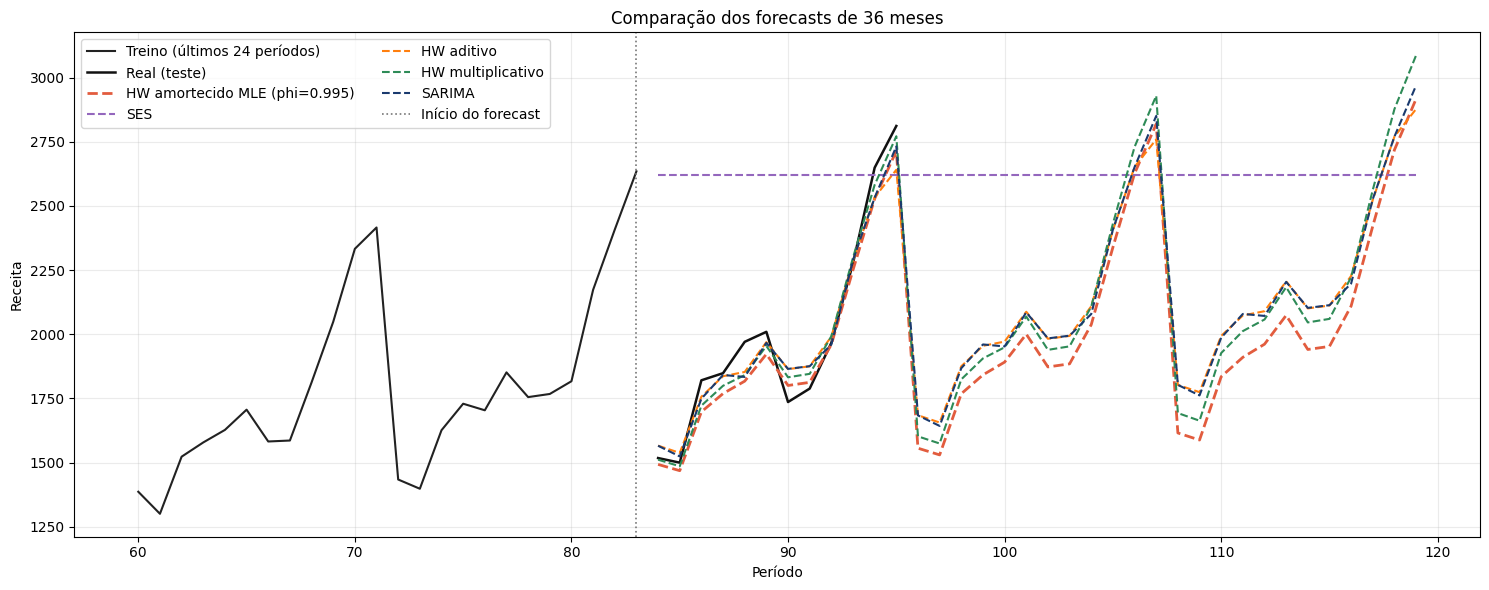

In [35]:
fc_ses_longo = ses.forecast(h_longo)
fc_add_longo = hw_add.forecast(h_longo)
fc_mul_longo = hw_mul.forecast(h_longo)
sarima_longo = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False, enforce_invertibility=False
 ).fit(disp=False)
fc_sarima_longo = sarima_longo.get_forecast(steps=h_longo).predicted_mean

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train.iloc[-24:].index, train.iloc[-24:], color='#222222', linewidth=1.5, label='Treino (últimos 24 períodos)')
ax.plot(test.index, test, color='#111111', linewidth=1.8, label='Real (teste)')
ax.plot(fc_mle.index, fc_mle, '--', color='#e25c3e', linewidth=2, label=f'HW amortecido MLE (phi={phi_mle:.3f})')
ax.plot(fc_ses_longo.index, fc_ses_longo, '--', color='#9467bd', linewidth=1.5, label='SES')
ax.plot(fc_add_longo.index, fc_add_longo, '--', color='#ff7f0e', linewidth=1.5, label='HW aditivo')
ax.plot(fc_mul_longo.index, fc_mul_longo, '--', color='#2e8b57', linewidth=1.5, label='HW multiplicativo')
ax.plot(fc_sarima_longo.index, fc_sarima_longo, '--', color='#1a3a6e', linewidth=1.5, label='SARIMA')
ax.axvline(train.index[-1], color='#777777', linestyle=':', linewidth=1.2, label='Início do forecast')
ax.set_title('Comparação dos forecasts de 36 meses')
ax.set_xlabel('Período')
ax.set_ylabel('Receita')
ax.legend(ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Comparação estatística dos modelos
A avaliação abaixo usa os mesmos 12 períodos de teste para todos os modelos. Quanto menores MAE, RMSE e MAPE, melhor; AIC e BIC são medidas de ajuste, também preferencialmente menores.

In [36]:
modelos_avaliacao = {
    'SES': (ses, ses.forecast(h)),
    'HW aditivo': (hw_add, hw_add.forecast(h)),
    'HW multiplicativo': (hw_mul, hw_mul.forecast(h)),
    'HW amortecido MLE': (hw_mul_damped, hw_mul_damped.forecast(h)),
    'HW amortecido phi=0.80': (modelo_phi_080, modelo_phi_080.forecast(h)),
    'SARIMA': (sarima_longo, sarima_longo.get_forecast(steps=h).predicted_mean),
}

metricas = []
for nome, (modelo, previsao) in modelos_avaliacao.items():
    erros = test - previsao
    mae = np.mean(np.abs(erros))
    rmse = np.sqrt(np.mean(erros ** 2))
    mape = np.mean(np.abs(erros / test)) * 100
    metricas.append({
        'modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'AIC': modelo.aic,
        'BIC': modelo.bic,
    })

comparacao_estatistica = pd.DataFrame(metricas).sort_values('MAE')
display(comparacao_estatistica.round(2))

print('Melhor modelo por métrica:')
for metrica in ['MAE', 'RMSE', 'MAPE (%)', 'AIC', 'BIC']:
    melhor = comparacao_estatistica.loc[comparacao_estatistica[metrica].idxmin(), 'modelo']
    valor = comparacao_estatistica.loc[comparacao_estatistica[metrica].idxmin(), metrica]
    print(f'{metrica}: {melhor} ({valor:.2f})')

,modelo,MAE,RMSE,MAPE (%),AIC,BIC
2,HW multiplicativo,55.12,65.86,2.81,681.78,720.67
5,SARIMA,63.48,78.00,3.21,622.96,631.13
3,HW amortecido MLE,69.82,83.44,3.45,684.78,726.10
1,HW aditivo,71.21,86.79,3.51,693.77,732.67
4,HW amortecido phi=0.80,109.04,127.89,5.21,701.63,742.95
0,SES,665.14,738.59,37.47,954.47,959.33


Melhor modelo por métrica:
MAE: HW multiplicativo (55.12)
RMSE: HW multiplicativo (65.86)
MAPE (%): HW multiplicativo (2.81)
AIC: SARIMA (622.96)
BIC: SARIMA (631.13)
